<a href="https://www.kaggle.com/code/matheusmarquezin/mental-health-kaggle?scriptVersionId=312157753" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / '.env').exists() and (PROJECT_ROOT.parent / '.env').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ENV_PATH = PROJECT_ROOT / '.env'
if ENV_PATH.exists():
    with open(ENV_PATH, encoding='utf-8') as env_file:
        for line in env_file:
            if line.startswith('MENTAL_HEALTH_CSV_PATH='):
                os.environ['MENTAL_HEALTH_CSV_PATH'] = line.split('=', 1)[1].strip()
                break

OUTPUT_DIR = PROJECT_ROOT / 'output' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Palette 
BG       = "#f7f5f2"
PANEL    = "#fffdf9"
TEXT     = "#2f2a24"
MUTED    = "#756a5c"
ACCENT   = "#d46a6a"
ACCENT_2 = "#8fb9a8"
ACCENT_3 = "#7c93c3"
GRID     = "#ddd6cf"
GOLD     = "#c49a4a"

PALETTE  = [ACCENT, ACCENT_2, ACCENT_3, GOLD, "#b07aa1", "#6f9ceb"]

# Typography 
FONT = {
    "section_title" : dict(fontsize=26, fontweight="bold",   color=TEXT),
    "section_sub"   : dict(fontsize=12, fontweight="normal", color=MUTED),
    "chart_title"   : dict(fontsize=18, fontweight="bold",   color=TEXT),
    "chart_sub"     : dict(fontsize=10, fontweight="normal", color=MUTED),
    "insight_title" : dict(fontsize=13, fontweight="bold",   color=TEXT),
    "insight_body"  : dict(fontsize=10, fontweight="normal", color=TEXT),
    "axis_label"    : dict(fontsize=11, fontweight="normal", color=MUTED),
    "tick"          : dict(fontsize=9,  fontweight="normal", color=MUTED),
}

def add_chart_titles(ax, title, subtitle=None, x=0, y_title=1.13, y_sub=1.05):
    ax.annotate(
        title,
        xy=(x, y_title),
        xycoords='axes fraction',
        **FONT["section_title"]
    )
    if subtitle:
        ax.annotate(
            subtitle,
            xy=(x, y_sub),
            xycoords='axes fraction',
            **FONT["section_sub"]
        )

def add_value_labels(ax, values, offset=0.9):
    for idx, value in enumerate(values):
        ax.text(
            value + offset,
            idx,
            f"{value:.1f}%",
            va='center',
            ha='left',
            fontsize=10,
            color=TEXT,
            fontweight='bold'
        )

def save_figure(fig, filename):
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

print('All libraries imported sucessfully')

All libraries imported sucessfully


In [2]:
import os
from pathlib import Path
import pandas as pd

dataset_path = os.getenv('MENTAL_HEALTH_CSV_PATH')

# fallback Kaggle
if not dataset_path:
    dataset_path = '/kaggle/input/datasets/jajidhasan/mental-health/mental_health.csv'

dataset_path = Path(dataset_path)

# local
if not dataset_path.is_absolute():
    dataset_path = PROJECT_ROOT / dataset_path

df = pd.read_csv(dataset_path)

df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2000, 18)


,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   Occupation                2000 non-null   object 
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   object 
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol 

In [4]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,577.494589,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,1.000000,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,1500.250000,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2000.000000,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
missing_values = df.isnull().sum()
missing_values

Person_ID                   0
Age                         0
Gender                      0
Occupation                  0
Daily_Screen_Time           0
Social_Media_Usage          0
Night_Usage                 0
Sleep_Hours                 0
Stress_Level                0
Work_Study_Hours            0
Physical_Activity           0
Social_Interaction_Score    0
Caffeine_Intake             0
Smoking                     0
Alcohol                     0
Depression                  0
Anxiety                     0
Burnout                     0
dtype: int64

In [6]:
df.corr(numeric_only=True)['Stress_Level'].sort_values(ascending=False)

Stress_Level                1.000000
Anxiety                     0.278755
Depression                  0.225461
Burnout                     0.208394
Alcohol                     0.027000
Smoking                     0.023596
Person_ID                   0.014206
Social_Interaction_Score    0.005909
Night_Usage                 0.005583
Social_Media_Usage         -0.003526
Daily_Screen_Time          -0.007215
Caffeine_Intake            -0.011395
Age                        -0.021641
Work_Study_Hours           -0.022692
Sleep_Hours                -0.028459
Name: Stress_Level, dtype: float64

In [7]:
df.groupby('Gender')[['Stress_Level', 'Anxiety']].corr()

Stress_Level   Anxiety
Gender                                     
Female Stress_Level      1.000000  0.301909
       Anxiety           0.301909  1.000000
Male   Stress_Level      1.000000  0.255820
       Anxiety           0.255820  1.000000

In [8]:
df.groupby('Gender')['Stress_Level'].mean()

Gender
Female    5.363095
Male      5.456653
Name: Stress_Level, dtype: float64

In [9]:
df.groupby('Gender')['Burnout'].mean()

Gender
Female    0.509921
Male      0.521169
Name: Burnout, dtype: float64

In [10]:
df.groupby('Gender')[['Caffeine_Intake', 'Alcohol']].mean()

,Caffeine_Intake,Alcohol
Gender,,
Female,2.073413,0.501984
Male,1.984879,0.524194


In [11]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 40, 60], labels=['Jovem', 'Adulto', 'Sênior'])
df.groupby(['Age_Group', 'Gender'])['Stress_Level'].mean().unstack()

/tmp/ipykernel_16/3369255275.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age_Group', 'Gender'])['Stress_Level'].mean().unstack()


Gender,Female,Male
Age_Group,,
Jovem,5.583710,5.675676
Adulto,5.127329,5.527697
Sênior,5.421505,5.285714


In [12]:
df[df['Age_Group'] == 'Jovem'].groupby('Gender')[['Stress_Level', 'Sleep_Hours']].corr()

Stress_Level  Sleep_Hours
Gender                                        
Female Stress_Level      1.000000    -0.036003
       Sleep_Hours      -0.036003     1.000000
Male   Stress_Level      1.000000    -0.037908
       Sleep_Hours      -0.037908     1.000000

In [13]:
df[df['Age_Group'] == 'Jovem'].groupby('Gender')[['Stress_Level', 'Daily_Screen_Time', 'Night_Usage']].corr().unstack()['Stress_Level']


,Stress_Level,Daily_Screen_Time,Night_Usage
Gender,,,
Female,1.0,0.054841,0.039884
Male,1.0,0.012078,0.073261


In [14]:
# Verificando a média de estresse por Ocupação e Gênero
df.groupby(['Occupation', 'Gender'])['Stress_Level'].mean().unstack()


Gender,Female,Male
Occupation,,
Employed,5.623563,5.265101
Student,5.219880,5.443478
Unemployed,5.231707,5.633238


In [15]:
df.groupby(['Occupation','Gender']).size().unstack()

Gender,Female,Male
Occupation,,
Employed,348,298
Student,332,345
Unemployed,328,349


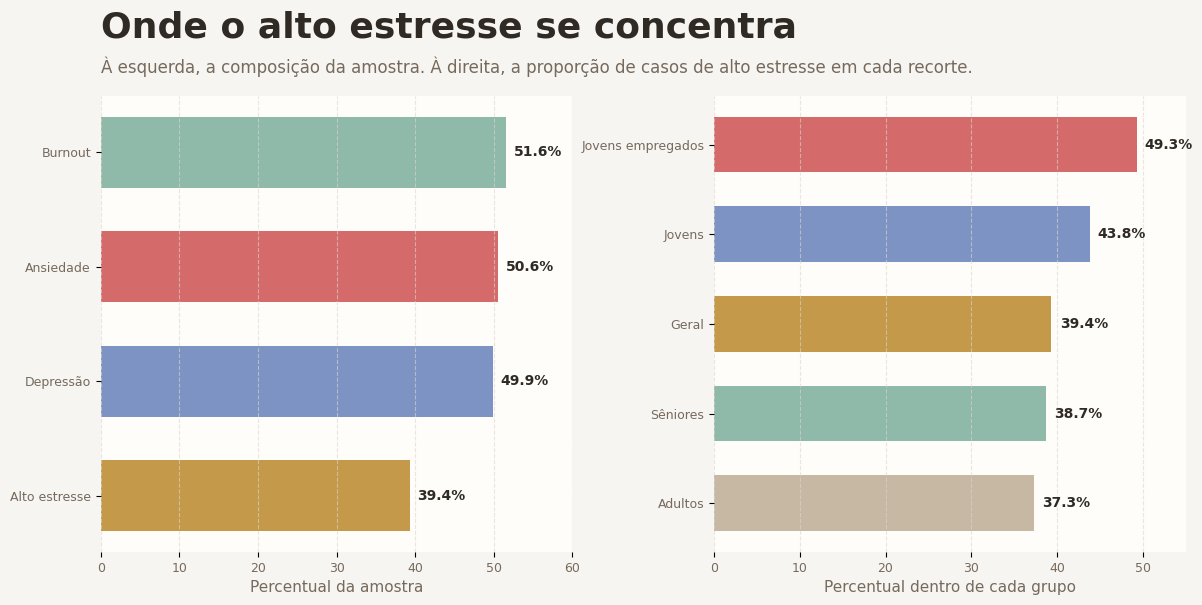

In [16]:
# Resumo executivo em percentuais
overview = pd.DataFrame(
    {
        'Indicador': ['Burnout', 'Ansiedade', 'Depressão', 'Alto estresse'],
        'Percentual': [
            df['Burnout'].mean() * 100,
            df['Anxiety'].mean() * 100,
            df['Depression'].mean() * 100,
            (df['Stress_Level'] >= 7).mean() * 100,
        ],
        'Color': [ACCENT_2, ACCENT, ACCENT_3, GOLD],
    }
)

young_employed = df.loc[(df['Age_Group'] == 'Jovem') & (df['Occupation'] == 'Employed'), 'Stress_Level']

high_stress_cuts = pd.DataFrame(
    {
        'Recorte': ['Jovens empregados', 'Jovens', 'Geral', 'Sêniores', 'Adultos'],
        'Percentual': [
            young_employed.ge(7).mean() * 100,
            df.loc[df['Age_Group'] == 'Jovem', 'Stress_Level'].ge(7).mean() * 100,
            df['Stress_Level'].ge(7).mean() * 100,
            df.loc[df['Age_Group'] == 'Sênior', 'Stress_Level'].ge(7).mean() * 100,
            df.loc[df['Age_Group'] == 'Adulto', 'Stress_Level'].ge(7).mean() * 100,
        ],
        'Color': [ACCENT, ACCENT_3, GOLD, ACCENT_2, '#c7b8a4'],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.8), facecolor=BG)
fig.subplots_adjust(top=0.78, wspace=0.3)

for axis in axes:
    axis.set_facecolor(PANEL)
    axis.tick_params(axis='both', labelsize=FONT['tick']['fontsize'], labelcolor=FONT['tick']['color'])
    axis.grid(axis='x', color=GRID, linestyle='--', alpha=0.6)
    sns.despine(ax=axis, left=True, bottom=True)

axes[0].barh(overview['Indicador'], overview['Percentual'], color=overview['Color'], edgecolor='none', height=0.62)
axes[0].invert_yaxis()
axes[0].set_xlim(0, 60)
axes[0].set_xlabel('Percentual da amostra', **FONT['axis_label'])
axes[0].set_ylabel('')
add_value_labels(axes[0], overview['Percentual'].round(1).tolist())

axes[1].barh(high_stress_cuts['Recorte'], high_stress_cuts['Percentual'], color=high_stress_cuts['Color'], edgecolor='none', height=0.62)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 55)
axes[1].set_xlabel('Percentual dentro de cada grupo', **FONT['axis_label'])
axes[1].set_ylabel('')
add_value_labels(axes[1], high_stress_cuts['Percentual'].round(1).tolist())

add_chart_titles(
    axes[0],
    title="Onde o alto estresse se concentra",
    subtitle="À esquerda, a composição da amostra. À direita, a proporção de casos de alto estresse em cada recorte.",
)

save_figure(fig, 'executive_summary.png')
plt.show()


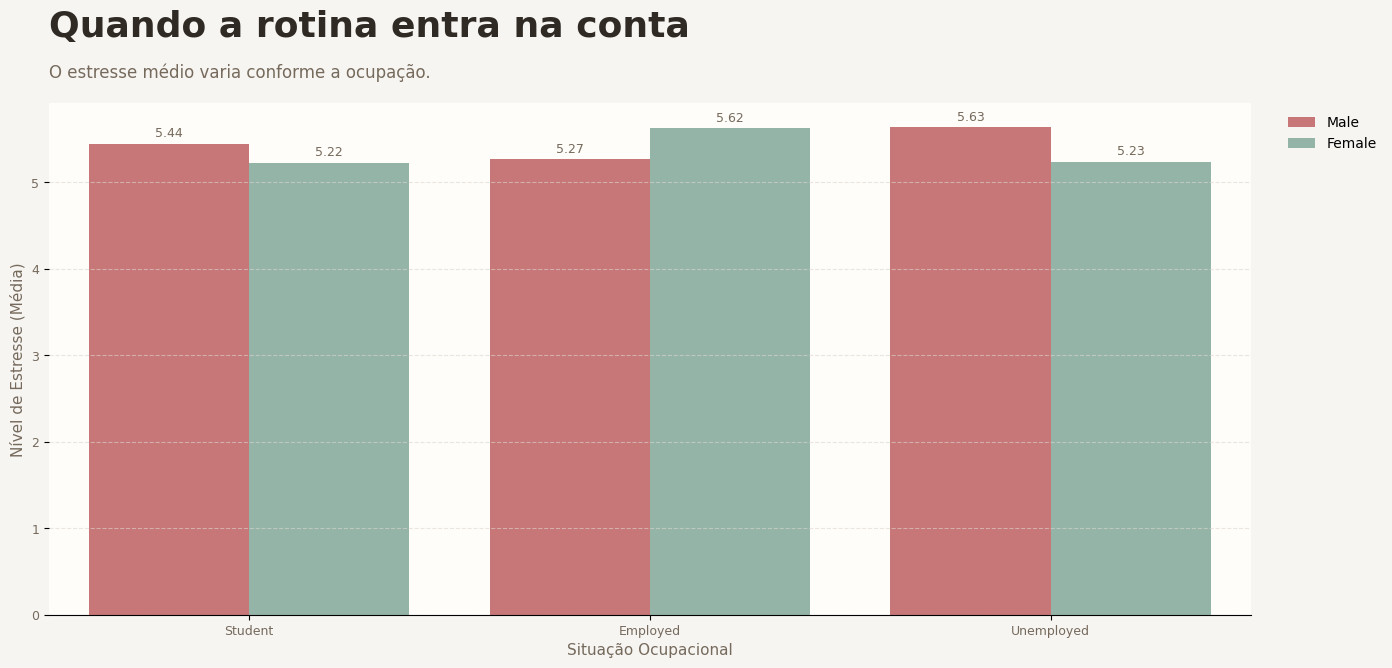

In [17]:
# Configura??o da figura
fig, ax = plt.subplots(figsize=(14, 6.8), facecolor=BG)
ax.set_facecolor(PANEL)

# Gr?fico de Barras
sns.barplot(
    data=df, 
    x='Occupation', 
    y='Stress_Level', 
    hue='Gender', 
    palette=[ACCENT, ACCENT_2],
    errorbar=None,
    ax=ax
)

# T?tulos e Subtitulos
add_chart_titles(
    ax,
    title="Quando a rotina entra na conta",
        subtitle="O estresse médio varia conforme a ocupação.",
)

# Eixos
ax.set_xlabel("Situação Ocupacional", **FONT["axis_label"])
ax.set_ylabel("Nível de Estresse (Média)", **FONT["axis_label"])
ax.tick_params(axis='both', which='major', labelsize=FONT["tick"]["fontsize"], labelcolor=FONT["tick"]["color"])

# Grade e Est?tica
ax.grid(axis='y', color=GRID, linestyle='--', alpha=0.6)
sns.despine(left=True, bottom=False)

# Legenda Neutra
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')

# Adicionando os valores
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, color=MUTED, fontsize=9)

plt.tight_layout()
save_figure(fig, 'stress_by_occupation.png')
plt.show()


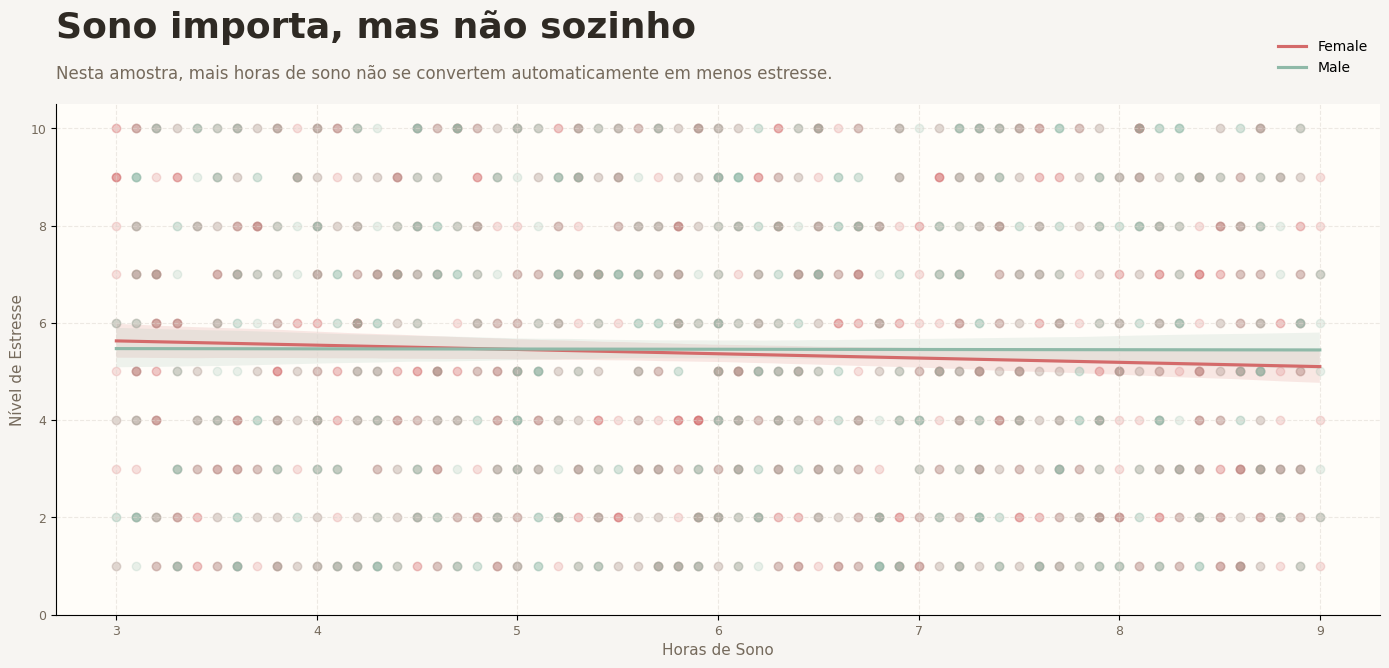

In [18]:
# Configura??o da figura
fig, ax = plt.subplots(figsize=(14, 6.8), facecolor=BG)
ax.set_facecolor(PANEL)

# Gr?ficos
sns.regplot(data=df[df['Gender'] == 'Female'], x='Sleep_Hours', y='Stress_Level', 
            scatter_kws={'alpha':0.2, 'color':ACCENT}, line_kws={'color':ACCENT, 'label':'Female'}, ax=ax)
sns.regplot(data=df[df['Gender'] == 'Male'], x='Sleep_Hours', y='Stress_Level', 
            scatter_kws={'alpha':0.2, 'color':ACCENT_2}, line_kws={'color':ACCENT_2, 'label':'Male'}, ax=ax)

# T?tulos e Subt?tulos
add_chart_titles(
    ax,
    title="Sono importa, mas não sozinho",
    subtitle="Nesta amostra, mais horas de sono não se convertem automaticamente em menos estresse.",
)

# Eixos
ax.set_xlabel("Horas de Sono", **FONT["axis_label"])
ax.set_ylabel("Nível de Estresse", **FONT["axis_label"])
ax.set_ylim(0, 10.5) 

# Grade e Est?tica
ax.tick_params(axis='both', labelsize=FONT["tick"]["fontsize"], labelcolor=FONT["tick"]["color"])
ax.grid(color=GRID, linestyle='--', alpha=0.5)
sns.despine()

# Legendas
plt.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 1.15))

plt.tight_layout()
save_figure(fig, 'sleep_vs_stress.png')
plt.show()


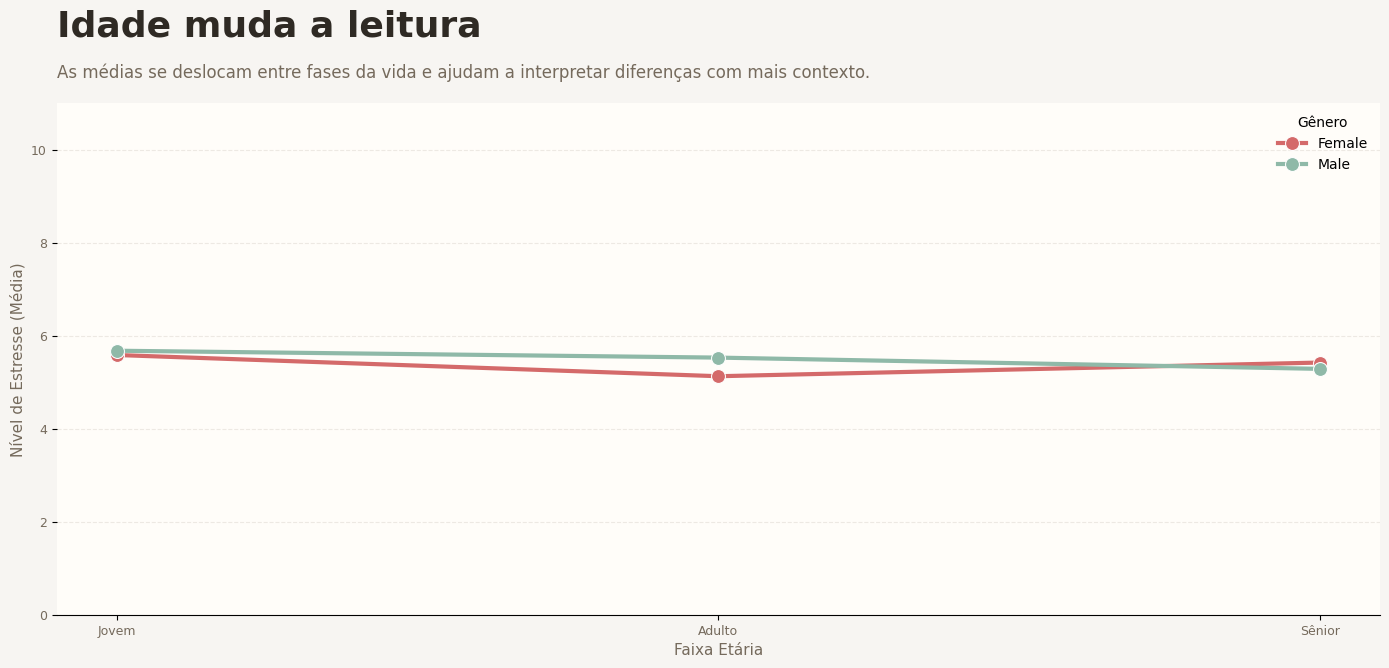

In [19]:
# Configura??es
age_stress = df.groupby(['Age_Group', 'Gender'], observed=True)['Stress_Level'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6.8), facecolor=BG)
ax.set_facecolor(PANEL)

# Gr?ficos
sns.lineplot(data=age_stress, x='Age_Group', y='Stress_Level', hue='Gender',
             palette=[ACCENT, ACCENT_2], marker='o', markersize=10, linewidth=3, ax=ax)

# T?tulos e Subt?tulos
add_chart_titles(
    ax,
    title="Idade muda a leitura",
    subtitle="As médias se deslocam entre fases da vida e ajudam a interpretar diferenças com mais contexto.",
)

# Eixos
ax.set_xlabel("Faixa Etária", **FONT["axis_label"])
ax.set_ylabel("Nível de Estresse (Média)", **FONT["axis_label"])

# Escala
ax.set_ylim(0, 11) 

# Grade e Est?tica
ax.tick_params(axis='both', labelsize=FONT["tick"]["fontsize"], labelcolor=FONT["tick"]["color"])
ax.grid(axis='y', color=GRID, linestyle='--', alpha=0.5)
sns.despine(left=True)

# Legenda
plt.legend(title="Gênero", frameon=False, loc='upper right', bbox_to_anchor=(1, 1.0))

plt.tight_layout()
save_figure(fig, 'stress_by_age_group.png')
plt.show()
